Utilizando data de kaggle sobre Job Postings de analista de datos, queremos responder tres preguntas principales:
1. ¿Qué habilidades son las más demandadas?
2. ¿Qué habilidades se asocian a salarios más altos?

# 2. Carga de datos

In [183]:
import pandas as pd
df = pd.read_csv(r"C:\Users\milto\Desktop\Proyectos\Mercado_laboral_analisis\Data\gsearch_jobs.csv")

# 3. Exploración inicial

In [184]:
df.columns

Index(['Unnamed: 0', 'index', 'title', 'company_name', 'location', 'via',
       'description', 'extensions', 'job_id', 'thumbnail', 'posted_at',
       'schedule_type', 'work_from_home', 'salary', 'search_term', 'date_time',
       'search_location', 'commute_time', 'salary_pay', 'salary_rate',
       'salary_avg', 'salary_min', 'salary_max', 'salary_hourly',
       'salary_yearly', 'salary_standardized', 'description_tokens'],
      dtype='object')

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           61953 non-null  int64  
 1   index                61953 non-null  int64  
 2   title                61953 non-null  object 
 3   company_name         61953 non-null  object 
 4   location             61916 non-null  object 
 5   via                  61944 non-null  object 
 6   description          61953 non-null  object 
 7   extensions           61953 non-null  object 
 8   job_id               61953 non-null  object 
 9   thumbnail            38194 non-null  object 
 10  posted_at            61763 non-null  object 
 11  schedule_type        61707 non-null  object 
 12  work_from_home       27980 non-null  object 
 13  salary               10088 non-null  object 
 14  search_term          61953 non-null  object 
 15  date_time            61953 non-null 

Primero, quiero ver qué columnas voy a borrar. 'Unnamed: 0' es una columna basura, que es copia de index. 'thumbnail' también es prescindible pues parece ser la URL de algún logo. Quiero ver qué tan importante es 'job_id'.

In [186]:
print(df["job_id"].nunique())
print("-----------------------------")
print(df.shape[0])

58775
-----------------------------
61953


Puede que hayan algunos duplicados, pues compartirían un mismo job_id. 

In [187]:
print(df.duplicated().sum(), "filas duplicadas y", df["job_id"].duplicated().sum(), "job_id duplicados")
len(df)

0 filas duplicadas y 3178 job_id duplicados


61953

 Hay filas con el mismo job_id pero que pueden diferir en otras columnas. Puede que difierean en la manera que se buscaron los trabajos (search_term) o la plataforma en la que se buscaron. Vamos a verificar esto.

In [188]:
df["job_id"].value_counts().head(10) 

job_id
eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJjb21wYW55X25hbWUiOiJDaXR5IG9mIEdyYW5kIEp1bmN0aW9uIiwiYWRkcmVzc19jaXR5IjoiR3JhbmQgSnVuY3Rpb24sIENPIiwiaHRpZG9jaWQiOiJ6cGRhajBnTFBNSkNPSFJHQUFBQUFBPT0iLCJ1dWxlIjoidytDQUlRSUNJTlZXNXBkR1ZrSUZOMFlYUmxjdyIsImdsIjoidXMiLCJobCI6ImVuIn0=                                                                                            75
eyJqb2JfdGl0bGUiOiJIZWFsdGhjYXJlIERhdGEgQW5hbHlzdCwgQ2xhaW1zIGFuZCBBdXRob3JpemF0aW9ucyAqUmVtb3RlIGluIEJlYXZlcnRvbiwgT1IiLCJjb21wYW55X25hbWUiOiJ2bXlzbWFydHByb3MiLCJhZGRyZXNzX2NpdHkiOiJVbml0ZWQgU3RhdGVzIiwiaHRpZG9jaWQiOiJpUW1naHR6OEo4blVkMFc2QUFBQUFBPT0iLCJ1dWxlIjoidytDQUlRSUNJTlZXNXBkR1ZrSUZOMFlYUmxjdyIsImdsIjoidXMiLCJobCI6ImVuIn0=                            34
eyJqb2JfdGl0bGUiOiJSZXF1aXJlZCBEYXRhIEFuYWx5c3Qg4oCTIEpcdTAwMjZMIE1hcmtldGluZyDigJMgTG91aXN2aWxsZSwgS1kiLCJjb21wYW55X25hbWUiOiJ2bXlzbWFydHByb3MiLCJhZGRyZXNzX2NpdHkiOiJVbml0ZWQgU3RhdGVzIiwiaHRpZG9jaWQiOiJsUkJQYzRKWjA4aHp5OWNQQUFBQUFBPT0iLCJ1dWxlIjoidytDQUlRSUNJTlZXNXB

In [189]:
#vamos a ver el contenido de un job_id específico para ver en qué difieren las filas.
ejemplo = "eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJjb21wYW55X25hbWUiOiJDaXR5IG9mIEdyYW5kIEp1bmN0aW9uIiwiYWRkcmVzc19jaXR5IjoiR3JhbmQgSnVuY3Rpb24sIENPIiwiaHRpZG9jaWQiOiJ6cGRhajBnTFBNSkNPSFJHQUFBQUFBPT0iLCJ1dWxlIjoidytDQUlRSUNJTlZXNXBkR1ZrSUZOMFlYUmxjdyIsImdsIjoidXMiLCJobCI6ImVuIn0="
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 20)

df.loc[
    df["job_id"] == ejemplo,
    [
        "job_id",
        "date_time"
    ]
       
].nunique()


job_id        1
date_time    75
dtype: int64

In [190]:

duplicados = df[df["job_id"] == ejemplo]

duplicados.nunique()

Unnamed: 0             75
index                  74
title                   1
company_name            1
location                1
                       ..
salary_max              1
salary_hourly           0
salary_yearly           0
salary_standardized     1
description_tokens      1
Length: 27, dtype: int64

Existen 75 `date_time` para un solo `job_id`. El scraper quizás fue tomando las mismas ofertas a lo largo del tiempo. Sin embargo también hay duplicados en descripicón y extensión. Vamos a revisarlos.

In [191]:
duplicados["extensions"].unique()

array(["['6,390.80–7,191.60 a month', 'Full-time', 'Health insurance', 'Paid time off', 'Dental insurance']",
       "['6,390.80–7,191.60 a month', 'Full-time', 'Dental insurance', 'Health insurance', 'Paid time off']",
       "['6,390.80–7,191.60 a month', 'Full-time', 'Paid time off', 'Dental insurance', 'Health insurance']",
       "['6,390.80–7,191.60 a month', 'Full-time', 'Health insurance', 'Dental insurance', 'Paid time off']",
       "['6,390.80–7,191.60 a month', 'Full-time', 'Paid time off', 'Health insurance', 'Dental insurance']",
       "['6,390.80–7,191.60 a month', 'Full-time', 'Dental insurance', 'Paid time off', 'Health insurance']"],
      dtype=object)

In [192]:
duplicados["description"].unique()

array(["DATA ANALYST\nHiring Range: $6,390 - $7,191 Monthly\nOpen until filled.\nNew to the City? Receive 40 Hours Paid Time Off Upon Hire!\nUp to $2,500 in Relocation Reimbursement\n\nAbout the Position:\nAs a Data Analyst with Visit Grand Junction, you will play a key role in formulating and applying statistical modeling to collect, analyze, interpret, and visualize data. Your work will yield actionable insights and optimize the team's destination marketing efforts.\n\nAbout Visit Grand Junction:\nVisit Grand Junction (Visit GJ), the Destination Marketing Organization, is a Department of the City of Grand Junction. Visit GJ is dedicated to marketing the Grand Junction area, outside of Mesa County, to attract year-round tourism, thereby providing for a sustainable and consistent economy and enhanced quality of life for residents. The team consists of dynamic individuals who are culture-focused, innovative, driven, and dedicated to supporting the travel and tourism industry while reach

In [193]:
df["job_id"].value_counts().describe()

count    58775.000000
mean         1.054071
std          0.761681
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         75.000000
Name: count, dtype: float64

Encontramos que las ofertas con diferentes job_id corresponden a la misma oferta pero con cambios en: hora en la que se capturó la oferta, descripción o extensiones. Consideraremos más adelante eliminar estos duplicados para conservar una única observación por job_id, pues nuestro objetivo es analizar ofertas laborales y no eventos de captura.

Ahora veremos qué porcentaje de nulos hay en cada columna

In [194]:
df.isna().mean().sort_values(ascending=False).mul(100).round(2)

commute_time          100.00
salary_yearly          93.43
salary_hourly          90.48
salary_max             84.65
salary_min             84.65
                       ...  
description             0.00
date_time               0.00
search_location         0.00
search_term             0.00
description_tokens      0.00
Length: 27, dtype: float64

Queremos ver cómo obtener información sobre las habilidades pedidas. Podremos encontrar las etiquetas en la columna `description_tokens`. Vimos arriba que está columna está 100% completa, pero al analizarla nos encontramos con valores vacíos. Esto es porque un valor vacío [] no cuenta como nulo. 

In [195]:
df["description_tokens"].value_counts()

description_tokens
[]                                               13352
['excel']                                         2215
['sql']                                           2058
['excel', 'sql']                                  1011
['tableau', 'sql']                                 419
                                                 ...  
['tableau', 'excel', 'sas', 'sql', 'python']         1
['ssis', 'ssrs', 'sql', 'r']                         1
['java', 'go', 'mysql', 'word']                      1
['word', 'aws', 'python', 'snowflake', 'sql']        1
['powerpoint', 'excel', 'python', 'sas']             1
Name: count, Length: 11276, dtype: int64

Hay 13352 valores vacíos que no nos sirven para contabilizar la demanda ante diferentes tipos de habilidad. Exploraremos la opción alternativa para identificar las diferentes habilidades a partir de la descripción de cada oferta de trabajo.

In [196]:
df[["salary_hourly",
    "salary_yearly",
    "salary_standardized"]].isna().mean().mul(100).round(2)

salary_hourly          90.48
salary_yearly          93.43
salary_standardized    83.72
dtype: float64

Para los salarios, se nota la existencia de múltiples valores nulos, además de diferentes columnas de las cuales podemos extraer información similar, sea salario por hora, anual o estandarizada. Se explorarán opciones para obtener las métricas necesarias de la manera más eficiente.

ACÁ FALTA MOSTRAR LO DE TRABAJO REMOTO: 54% ERA NO REMOTO PERO DEBO BUSCAR UNA FORMA DE BUSCAR EN LAS DESCRIPCIONES PARA CACHAR QUE ONDA- USAR PD.CROSSTAB.

In [197]:
df["work_from_home"].value_counts(dropna=False)

work_from_home
NaN     33973
True    27980
Name: count, dtype: int64

In [198]:
contiene_remoto = df["description"].str.contains(r"work from home|hybrid|remote", case=False, na=False, regex=True)
#esto entrega True o False.
#.count entrega cuántas filas existen.
#.sum entrega cuántas filas cumplen la condición.


In [199]:
contiene_remoto.value_counts()

description
False    38298
True     23655
Name: count, dtype: int64

In [200]:
pd.crosstab(
    df["work_from_home"].fillna(False),
    contiene_remoto
)

C:\Users\milto\AppData\Local\Temp\ipykernel_14528\1320476819.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["work_from_home"].fillna(False),


description,False,True
work_from_home,,
False,23129,10844
True,15169,12811


De los 27980 valores que eran marcados como remotos por la información original, solo 12811 contienen las palabras buscadas en la descripción. Es decir, menos de la mitad. Y de las 33973 posiciones sin registro, 23129 de ellas no las contienen. Esto no incluye la opción de trabajo híbrido. Es decir, no sabemos si los valores falsos de la columna `work_from_home` corresponden a ofertas de puestos sin trabajo remoto o a ofertas que sí lo ofrecen pero que el scraper no lo detectó, llevando a que no se puedan interpretar los diferentes puestos de manera confiable. Se decidió excluir el análisis respecto a frecuencia de trabajos remotos para analistas de datos.

# 4. Feature Engineering 

🔷 Feature Engineering

Dado que las variables existentes no permiten un análisis directo de habilidades técnicas ni de remuneraciones comparables, se procederá a generar nuevas variables derivadas del dataset.

🔹 Extracción de habilidades

Se construirá una variable estructurada de habilidades técnicas a partir de la columna description, utilizando un enfoque basado en detección de palabras clave. Esto permite transformar texto no estructurado en una representación analizables de competencias demandadas en el mercado laboral.

La columna description_tokens no será utilizada debido a su alta proporción de valores faltantes.


In [201]:
import re
habilidades_mapa = {
    "python": ["python"],
    "sql": ["sql"],
    "powerbi": ["powerbi", "power bi"],
    "excel": ["excel"],
    "tableau": ["tableau"],
    "azure": ["azure"],
    "r": [" r ", " r,"],
    "machine_learning": ["machine learning"],
    "aws": ["aws"]
}
"""""
def extraccion(desc, habilidades_mapa):
    desc = str(desc).lower() #convertimos todo a minúsculas (Python vs python, SQL vs sql)
    habilidades_finales = []

    for habilidad, keyword in habilidades_mapa.items():
        for kw in keyword:
            if kw in desc:
                habilidades_finales.append(habilidad)
                break
    return habilidades_finales
"""""
def extraccion(desc, habilidades_mapa):
    desc = str(desc).lower()
    habilidades_finales = []

    for habilidad, keywords in habilidades_mapa.items():
        for kw in keywords:
            pattern = rf"\b{re.escape(kw)}\b"
            if re.search(pattern, desc):
                habilidades_finales.append(habilidad)
                break

    return habilidades_finales
df["habilidades"] = df["description"].apply(lambda x: extraccion(x, habilidades_mapa))
df["habilidades"].explode().value_counts()

habilidades
sql                 31914
excel               20174
python              19427
tableau             17361
powerbi             16407
machine_learning     6367
azure                4006
aws                  3808
r                    2260
Name: count, dtype: int64

In [202]:
len(df["habilidades"])

61953

Ahora evaluamos qué tan eficiente fue nuestra extracción. En la siguiente tabla veremos que algunos valores de la columna `habilidades` quedaron vacíos. Esto era de esperar ya que nuestro extractor depende de un conjunto predefinido de palabras claves. Veremos cuántos valores vacíos quedaron.

In [203]:
df[["salary_standardized","habilidades"]]

,salary_standardized,habilidades
0,122000.0,"[python, sql, tableau]"
1,NaN,[]
2,NaN,[sql]
3,41600.0,"[powerbi, excel]"
4,100000.0,[excel]
...,...,...
61948,103781.0,"[python, sql, powerbi, excel, tableau]"
61949,144481.5,[]
61950,144481.5,[]
61951,144481.5,[]


In [204]:
(df["habilidades"].str.len() == 0).sum()

np.int64(15777)

In [205]:
(df["habilidades"].str.len() == 0).mean() * 100

np.float64(25.466079124497604)

DE 61953, solo 15777 ofertas quedaron con un conjunto de habilidades vacías. Esto significa un 25% de los valores totales, o bien, un cuarto del conjunto completo. 


🔹 Preparación de variables salariales

Para el análisis de remuneraciones se utilizará la variable `salary_standardized`, ya que permite la comparación entre ofertas bajo una escala común.

Debido a la presencia de valores nulos en esta variable, se trabajará inicialmente con el subconjunto de registros con información salarial disponible.


In [206]:
print("el porcentaje de nulos para salarios estandarizados es:", df["salary_standardized"].isna().mean() * 100)
print("sus valores no nulos son:", df["salary_standardized"].notna().sum())

el porcentaje de nulos para salarios estandarizados es: 83.71668845737898
sus valores no nulos son: 10088


A pesar de que el 83% de los valores son nulos, aún nos deja con 10088 entradas de ofertas. Esto es un tamaño muestral suficiente para realizar análisis exploratorios dentro del mercado laboral. También, con la siguiente tabla queremos mostrar que la columna `salary_standardized` es, en efecto, una métrica consistente con las otras columnas de salario.

In [207]:
#df[["salary_rate","salary_standardized"]].dropna().head(20)
df.loc[
    df["salary_standardized"].notna(),
    [
        "salary",
        "salary_rate",
        "salary_pay",
        "salary_standardized",
        "habilidades"
    ]
].head(10)

,salary,salary_rate,salary_pay,salary_standardized,habilidades
0,101K–143K a year,a year,101K–143K,122000.0,"[python, sql, tableau]"
3,15–25 an hour,an hour,15–25,41600.0,"[powerbi, excel]"
4,90K–110K a year,a year,90K–110K,100000.0,[excel]
10,54.00–60.52 an hour,an hour,54.00–60.52,119100.8,[sql]
14,90K–130K a year,a year,90K–130K,110000.0,"[sql, excel]"
21,18.33–28.20 an hour,an hour,18.33–28.20,48391.2,[]
26,50–80 an hour,an hour,50–80,135200.0,[]
39,8–30 an hour,an hour,8–30,39520.0,[]
49,95K–150K a year,a year,95K–150K,122500.0,[sql]
65,60–65 an hour,an hour,60–65,130000.0,"[sql, tableau]"


In [208]:
df_salary = df[df["salary_standardized"].notna()].copy()
df_salary.shape

(10088, 28)

In [209]:
df_salary[["salary_standardized","habilidades"]]

,salary_standardized,habilidades
0,122000.0,"[python, sql, tableau]"
3,41600.0,"[powerbi, excel]"
4,100000.0,[excel]
10,119100.8,[sql]
14,110000.0,"[sql, excel]"
...,...,...
61948,103781.0,"[python, sql, powerbi, excel, tableau]"
61949,144481.5,[]
61950,144481.5,[]
61951,144481.5,[]


Tal como antes con la columna de `habilidades` en la data original, revisaremos cuántos valores vacíos existen en el subconjunto creado para los salarios funcionales.

In [210]:
(df_salary["habilidades"].str.len() == 0).mean() * 100

np.float64(31.245043616177636)

In [211]:
len(df_salary)-(df_salary["habilidades"].str.len() == 0).sum()

np.int64(6936)

Nos queda un total de 6396 valores con información útil obtenida de nuestra función de extracción, lo que es suficiente para realizar un análisis sobre la relación entre las habilidades demandadas y el salario esperado.

# 5. Limpieza de datos

Debido a la existencia de valores vacíos en la columna `habilidades`, nos quedaremos con la información sobre las ofertas donde nuestro extractor logró identificar las palabras claves desde las descripciones de cada oferta.

In [212]:
df_salary_skills = df_salary[df_salary["habilidades"].apply(len) > 0].copy()
len(df_salary_skills)


6936

Para responder las preguntas planteadas en este proyecto, no necesitamos todas las columnas. Se creará un dataset dedicado a la visualización de la información esperada, en este caso, habilidades y salarios normalizados. Incluiremos también el título para una representación más completa.

In [213]:
df_analisis = df_salary_skills[
    ["title","salary_standardized","location","habilidades"]
]
df_analisis

,title,salary_standardized,location,habilidades
0,Data Analyst,122000.0,Anywhere,"[python, sql, tableau]"
3,Data Analyst - Consumer Goods - Contract to Hire,41600.0,Anywhere,"[powerbi, excel]"
4,Data Analyst | Workforce Management,100000.0,United States,[excel]
10,Senior Data Analyst,119100.8,Anywhere,[sql]
14,Mid-level Claims Data Analyst,110000.0,United States,"[sql, excel]"
...,...,...,...,...
61915,Data Analyst II,103781.0,"St James, MO","[python, sql, powerbi, excel, tableau]"
61938,Data Analyst II,103781.0,"Rolla, MO","[python, sql, powerbi, excel, tableau]"
61939,Data Analyst II,103781.0,"St James, MO","[python, sql, powerbi, excel, tableau]"
61948,Marketing Data & BI Analyst II,103781.0,"Houstonia, MO","[python, sql, powerbi, excel, tableau]"


Hallamos la existencía de múltiples ofertas con el mismo título, salario y habilidades pedidas.

In [214]:
df_analisis[["title","salary_standardized"]].duplicated().sum()

np.int64(2671)

In [215]:
df_analysis_temp = df_analisis.copy()

df_analysis_temp["habilidades"] = (
    df_analysis_temp["habilidades"]
    .apply(tuple)
)

df_analysis_temp[["title","salary_standardized","habilidades"]].duplicated().sum()

np.int64(2166)

In [216]:
df_analysis_temp[
    df_analysis_temp.duplicated(keep=False)
].head(20)

,title,salary_standardized,location,habilidades
49,Production Support Data Analyst (Open),122500.00,United States,"(sql,)"
138,CRM Analyst,77500.00,United States,"(powerbi, excel)"
139,CRM Analyst,77500.00,United States,"(powerbi, excel)"
140,Data analyst-pharmaceutical,88400.00,Anywhere,"(python, r, machine_learning)"
154,Data analyst-pharmaceutical,88400.00,Anywhere,"(python, r, machine_learning)"
155,Data Analyst,31200.00,"Joplin, MO","(sql, excel)"
307,IT Analyst / System Analyst - Contract to Hire,119600.00,Anywhere,"(sql,)"
399,Financial Data Guru (SQL/Excel),100000.00,United States,"(sql, excel)"
464,Data Analyst with Mongo DB,106111.20,"Denver, CO","(python, sql)"
470,Data Analyst,60100.00,"Gunnison, CO","(sql,)"


Hay 2671 filas con el mismo título y salario pero con diferentes habilidades, pero 2166 también con las mismas habilidades. Es decir, estos últimos son duplicados verdaderos. Vamos a eliminarlos. 

In [225]:
df_analisis_final = df_analysis_temp.drop_duplicates()
#df_analisis_final["habilidades"].explode("habilidades").value_counts()
len(df_analisis_final)

5169

Debido a los duplicados encontrados por inspección manual, se decidió eliminar las 2166 filas correspondientes a ofertas que el scraper tomó más de una vez. Esto tiene sentido debido a que en la exploración inicial también encontramos mismas ofertas pero con distintos valores en `job_id`, `extensions` o `description`. Sin embargo, decidimos mantener ofertas que solo difieren en la ubicación, pues se trata de la misma vacante publicada en una diferente ciudad. El valor final de ofertas a analizar es de 5169.

 Los gráficos que veremos a continuación no son alterados por los duplicados de ubicación, como veremos adelante. Se mantuvo esta columna únicamente para generar una visualización más completa en un dashboard.


In [218]:

df_analisis_final.to_csv(r"C:\Users\milto\Desktop\Proyectos\Mercado_laboral_analisis\Data\clean.csv")

## 6. Análisis

In [226]:
import matplotlib.pyplot as plt
df_exploded = df_analisis_final.explode("habilidades")
df_exploded[["title","habilidades"]]

,title,habilidades
0,Data Analyst,python
0,Data Analyst,sql
0,Data Analyst,tableau
3,Data Analyst - Consumer Goods - Contract to Hire,powerbi
3,Data Analyst - Consumer Goods - Contract to Hire,excel
...,...,...
61948,Marketing Data & BI Analyst II,python
61948,Marketing Data & BI Analyst II,sql
61948,Marketing Data & BI Analyst II,powerbi
61948,Marketing Data & BI Analyst II,excel


In [227]:
skill_summary = (
    df_exploded
    .groupby("habilidades")
    .agg(
        frecuencia=("habilidades", "count"),
        salario_mediano=("salary_standardized", "median"),
        salario_promedio=("salary_standardized", "mean")
    )
    .sort_values("frecuencia", ascending=False)
)
skill_summary

,frecuencia,salario_mediano,salario_promedio
habilidades,,,
sql,3300,97000.0,100211.770329
excel,2267,82500.0,85473.954907
python,1966,103542.0,106782.512487
tableau,1794,96500.0,99350.600309
powerbi,1607,91959.5,93368.821301
machine_learning,641,110000.0,115729.096279
aws,476,106080.0,113618.088372
azure,409,107500.0,108234.794413
r,247,93600.0,97862.468846


Las ofertas que requieren conocimientos de aws o machine learning presentan los salarios medianos más altos del conjunto analizado.

Las habilidades más demandadas correspondel a SQL, EXCEL, Power bi/Tableau y python. Este hallazgo coincide al considerar que son los conocimientos fundamentales para el perfil esperado de analistas de datos..

Cabe notar que los salarios presentes no representan el efecto aislado de cada habilidad. Una oferta puede incluir múltiples competencias en demanda, entonces los salarios deben interpretarse como asociaciones entre la presencia de dichas habilidades y los valores de las remuneraciones, y no como una relación causal. 

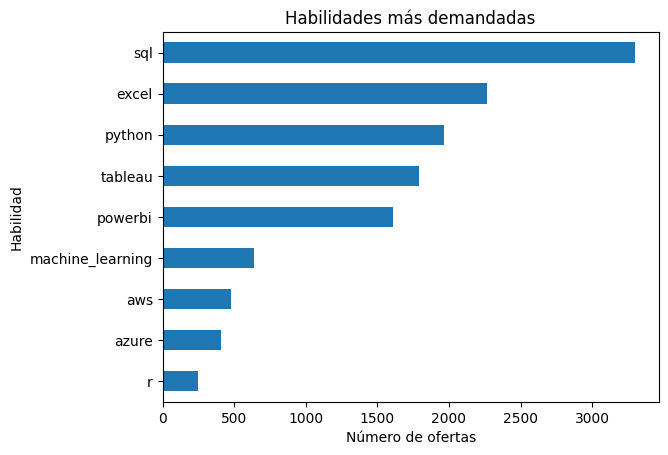

In [228]:
skill_summary["frecuencia"].sort_values().plot(kind="barh")

plt.title("Habilidades más demandadas")
plt.xlabel("Número de ofertas")
plt.ylabel("Habilidad")
plt.show()

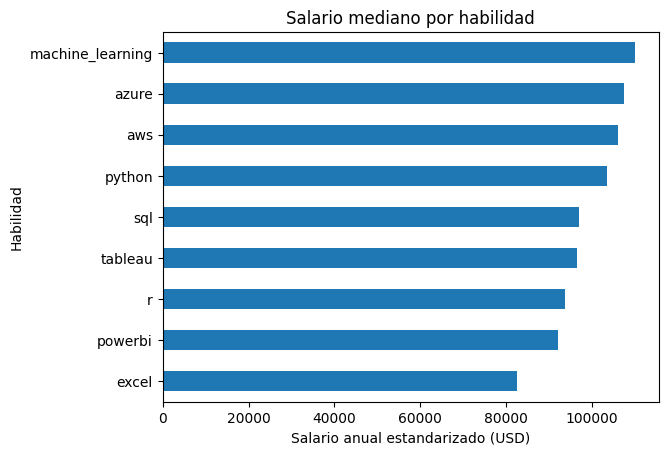

In [229]:
skill_summary["salario_mediano"].sort_values().plot(kind="barh")

plt.title("Salario mediano por habilidad")
plt.xlabel("Salario anual estandarizado (USD)")
plt.ylabel("Habilidad")
plt.show()

El siguiente código es para exportar la información en dos diferentes archivos separados por comas para una visualización en Powerbi.

In [230]:
ofertas = df_analisis_final.copy()

ofertas.insert(0, "id", range(1, len(ofertas) + 1))

competencias = (
    ofertas[["id", "habilidades"]]
    .explode("habilidades")
    .rename(columns={"habilidades": "habilidad"})
)

ofertas = ofertas.drop(columns="habilidades")

#se producían errores al cargar los datos en powerbi por saltos de línea en ciertos títulos. para arreglarlo,
ofertas["title"] = (
    ofertas["title"]
    .str.replace(r"[\r\n]+", " ", regex=True)
    .str.strip()
)
#algunos decimales muy grandes también estaban produciendo errores.
ofertas["salary_standardized"] = ofertas["salary_standardized"].round(2).astype(int)

ofertas.to_csv(r"C:\Users\milto\Desktop\Proyectos\Mercado_laboral_analisis\Data\ofertas.csv", index=False)
competencias.to_csv(r"C:\Users\milto\Desktop\Proyectos\Mercado_laboral_analisis\Data\competencias.csv", index=False)